## Figure S2B. Taxonomy agreement between complete genomes and simulated fragments.

### Setup taxonomy and lifestyle benchmarks

In [ ]:
### Download complete UHGV species representatives
# Extract UHGV complete genomes that are vOTU representatives
!wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_hq_plus.fna.gz
!wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv

import polars as pl

uhgv_complete_genomes = (
    pl.read_csv('uhgv_metadata.tsv', separator='\t', ignore_errors=True)
        .filter(
            (pl.col('checkv_quality') == 'Complete') &
            (pl.col('votu_representative') == "Yes")
        )
)
uhgv_complete_genomes[['uhgv_genome']].write_csv('uhgv_complete_votu_reps.txt')

!seqkit grep \
    uhgv_hq_plus.fna.gz \
    --pattern-file uhgv_complete_votu_reps.txt \
    --threads 4 \
    -o uhgv_complete_genomes_votu_reps.fna.gz

In [ ]:
%%bash
## Extract 5 random subsets of 1,000 complete genomes for testing
mkdir -p complete_genomes

for i in {1..5}; do
    seqkit seq \
        uhgv_complete_genomes_votu_reps.fna.gz \
        --min-len 20000 \
    | seqkit shuffle --rand-seed ${i} \
    | seqkit head -n 1000 \
        -o complete_genomes/uhgv_complete_votu_reps_rand1000_${i}.fna.gz

done

In [ ]:
# write function to extract X random subsequence of length Y from each sequence in a FASTA file
import gzip
import random
from Bio import SeqIO
import os

def extract_random_subsequences(input_fasta, output_fasta, X, Y):
    if os.path.exists(output_fasta):
        print(f"Output file {output_fasta} already exists. Skipping extraction.")
        return
    with gzip.open(input_fasta, 'rt') if input_fasta.endswith('.gz') else open(input_fasta, 'r') as input_fasta:
        with open(output_fasta, 'w') as out_f:
            for record in SeqIO.parse(input_fasta, "fasta"):
                for _ in range(X):
                    seq_len = len(record.seq)
                    if seq_len < Y:
                        print(f"Skipping {record.id}: sequence length < {Y}")
                        continue
                    start = random.randint(0, seq_len - Y)
                    subseq = record.seq[start:start + Y]
                    new_record = record[:]
                    new_record.seq = subseq
                    new_record.id = f"{record.id}_iter{_}_subseq{start}_{start + Y - 1}"
                    SeqIO.write(new_record, out_f, "fasta")

# Example usage:
# extract_random_subsequences("input.fasta", "output.fasta", 5, 10000)

In [ ]:
### create 5 replicates of 1000 random fragments of length 10kb
!mkdir -p phage_fragments

for i in [1, 2, 3, 4, 5]:
    for j in [1]:
        for N in [10000]:
            extract_random_subsequences(
                f"complete_genomes/uhgv_complete_votu_reps_rand1000_{i}.fna.gz",
                f"phage_fragments/uhgv_complete_votu_reps_rand1000_{i}_num{j}_len{N}.fa",
                j,
                N
            )

In [ ]:
# write function to extract X random subsequences of containing N% of each genome
import gzip
import random
from Bio import SeqIO
import os

def extract_random_subsequences_percentage(input_fasta, output_fasta, X, percentage):
    if os.path.exists(output_fasta):
        print(f"Output file {output_fasta} already exists. Skipping extraction.")
        return
    with gzip.open(input_fasta, 'rt') if input_fasta.endswith('.gz') else open(input_fasta, 'r') as input_fasta:
        with open(output_fasta, 'w') as out_f:
            for record in SeqIO.parse(input_fasta, "fasta"):
                for _ in range(X):
                    seq_len = len(record.seq)
                    N = int(seq_len * percentage / 100)
                    if seq_len < N:
                        print(f"Skipping {record.id}: sequence length < {N}")
                        continue
                    start = random.randint(0, seq_len - N)
                    subseq = record.seq[start:start + N]
                    new_record = record[:]
                    new_record.seq = subseq
                    new_record.id = f"{record.id}_iter{_}_subseq{start}_{start + N - 1}"
                    SeqIO.write(new_record, out_f, "fasta")

# Example usage:
# extract_random_subsequences("input.fasta", "output.fasta", 100)

In [ ]:
### create 5 replicates of 1000 random fragments containing 50% and 90% of each genome
!mkdir -p phage_fragments

for i in [1, 2, 3, 4, 5]:
    for j in [1]:
        for N in [50, 90]:
            extract_random_subsequences_percentage(
                f"complete_genomes/uhgv_complete_votu_reps_rand1000_{i}.fna.gz",
                f"phage_fragments/uhgv_complete_votu_reps_rand1000_{i}_num{j}_len{N}.fa",
                j,
                N
            )

In [ ]:
%%bash
### run genomad on all fragments and complete genomes
# this code was run on eacjh of the fragment sets and complete genomes separately
genomad \
    end-to-end \
    ${complete_genome_fasta} \
    ./ \
    genomad_db \
    --lenient-taxonomy \
    --threads 8 \
    --relaxed \
    --splits 5

In [1]:
### Load taxonomy results for fragmented viruses
import polars as pl
import glob

frag_summary_lst = []

for file in glob.glob("genomad_results/uhgv_complete_votu_reps_rand1000_*_*/uhgv_complete_votu_reps_rand1000_*_*/uhgv_complete_votu_reps_rand1000_*_*_virus_summary.tsv"):
    sample= file.rpartition('/')[-1].split('rand1000_')[1].split('_agg')[0]
    df = (
        pl.read_csv(file, separator="\t")
            .with_columns([
                pl.lit(sample).str.split('_len').list[1].str.split('_virus').list[0].alias('cat'),
                pl.lit(sample).str.split('_').list[0].str.replace('iter', '').cast(pl.Float64).alias('iter'),
                pl.col('seq_name').str.split('_').list[0].alias('contig_id'),
            ])
            .with_columns([
                pl.when(pl.col('cat') == "10000")
                .then(pl.lit('10 Kb'))
                .when(pl.col('cat') == "50")
                .then(pl.lit('50% complete'))
                .otherwise(pl.lit('90% complete'))
                .alias('category')
            ])
            .group_by(['contig_id'])
            .first()
    )
    frag_summary_lst.append(df)

frag_summary_df = pl.concat(frag_summary_lst)

In [2]:
### Load taxonomy results for complete viruses
comp_summary_lst = []

for i in [1,2,3,4,5]:
    file = f"genomad_results/uhgv_complete_votu_reps_rand1000_{i}/uhgv_complete_votu_reps_rand1000_{i}_summary/uhgv_complete_votu_reps_rand1000_{i}_virus_summary.tsv"
    sample= file.rpartition('/')[-1].split('rand1000_')[1].split('_virus')[0]
    df = (
        pl.read_csv(file, separator="\t")
            .with_columns([
                pl.lit("complete").alias('cat'),
                pl.lit(sample).cast(pl.Float64).alias('iter'),
            ])
    )
    comp_summary_lst.append(df)

comp_summary_df = pl.concat(comp_summary_lst)

# combine complete and fragment summary dataframes
concat_summary_df = comp_summary_df.join(
    frag_summary_df,
    left_on=['seq_name', 'iter'],
    right_on=['contig_id', 'iter'],
    how='inner'
)

In [3]:
### calculate ratios and differences between complete and fragmented viruses
concat_summary_df = concat_summary_df.with_columns([
    (pl.col('virus_score_right') / pl.col('virus_score')).alias('virus_score_ratio'),
    (pl.col('virus_score') - pl.col('virus_score_right')).alias('virus_score_diff'),
    (pl.col('n_hallmarks_right') / pl.col('n_hallmarks')).alias('n_hallmarks_ratio'),
    (pl.col('n_hallmarks') - pl.col('n_hallmarks_right')).alias('n_hallmarks_diff')
])

In [4]:
### unpivot for plotting
ratio_plot = (
    concat_summary_df
        .unpivot(
            index=['category', 'iter', 'seq_name'],
            on=['virus_score_ratio', 'virus_score_diff', 'n_hallmarks_ratio', 'n_hallmarks_diff'],
        )
)

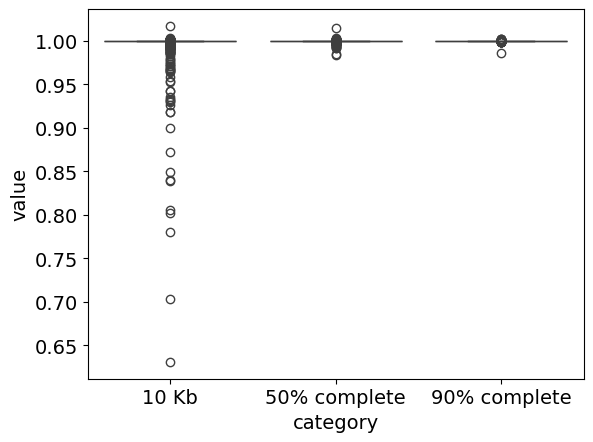

In [23]:
### Plot virus score ratio boxplots
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=ratio_plot.filter(pl.col('variable') == 'virus_score_ratio'), x='category', y='value', order=['10 Kb', '50% complete', '90% complete'])
plt.rcParams.update({'font.size': 14})
plt.show()
# Takeaway: virus score is not very affected by fragmentation!

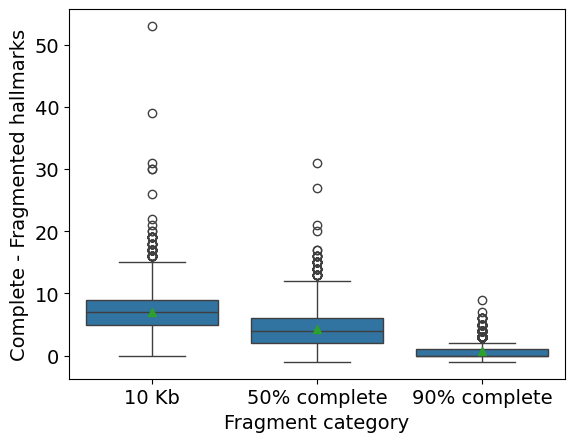

In [24]:
### Plot virus score difference boxplots
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=ratio_plot.filter(pl.col('variable') == 'n_hallmarks_diff'), showmeans=True, x='category', y='value', order=['10 Kb', '50% complete', '90% complete'])
plt.xlabel('Fragment category')
plt.ylabel('Complete - Fragmented hallmarks')
plt.rcParams.update({'font.size': 14})
plt.show()

# Takeaway: fragmentation reduces the number of detected virus hallmarks (difference is higher for more severe fragmentation)

In [15]:
### Load taxonomy results for fragmented viruses
import polars as pl

frag_tax_df = (
    frag_summary_df
        .filter(pl.col('taxonomy').str.contains(';'))
        .with_columns([
            pl.col('taxonomy').str.split(';').list[0].alias('domain'),
            pl.col('taxonomy').str.split(';').list[1].alias('realm'),
            pl.col('taxonomy').str.split(';').list[3].alias('kingdom'),
            pl.col('taxonomy').str.split(';').list[5].alias('phylum'),
            pl.col('taxonomy').str.split(';').list[7].alias('class'),
            pl.col('taxonomy').str.split(';').list[9].alias('order'),
            pl.col('taxonomy').str.split(';').list[11].alias('family'),
            pl.col('taxonomy').str.split(';').list[13].alias('genus'),
            pl.col('taxonomy').str.split(';').list[15].alias('species')
        ])
)

In [16]:
### Load taxonomy results for complete viruses
comp_tax_df = (
    comp_summary_df
        .filter(pl.col('taxonomy').str.contains(';'))
        .with_columns([
            pl.col('taxonomy').str.split(';').list[0].alias('domain'),
            pl.col('taxonomy').str.split(';').list[1].alias('realm'),
            pl.col('taxonomy').str.split(';').list[3].alias('kingdom'),
            pl.col('taxonomy').str.split(';').list[5].alias('phylum'),
            pl.col('taxonomy').str.split(';').list[7].alias('class'),
            pl.col('taxonomy').str.split(';').list[9].alias('order'),
            pl.col('taxonomy').str.split(';').list[11].alias('family'),
            pl.col('taxonomy').str.split(';').list[13].alias('genus'),
            pl.col('taxonomy').str.split(';').list[15].alias('species')
        ])
)

# join fragmented and complete taxonomy dataframes
tax_join_df = frag_tax_df.join(comp_tax_df, left_on='contig_id', right_on='seq_name', suffix='_complete', how='inner')

In [17]:
### Calculate taxonomic assignment accuracy at different levels
tax_analysis_lst = {
    "cat": [],
    "iter": [],
    "Taxonomic rank": [],
    "tp": [],
    "fp": [],
    "fn": [],
    "precision": [],
    "recall": []
}

for level in ['domain', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus']:
    for iter in [0, 1, 2, 3, 4]:
        for cat in ['10 Kb', '50% complete', '90% complete']:
            filt_df = (
                tax_join_df
                    .group_by(['contig_id', 'iter', 'category'])
                    .first()
            )

            tp = filt_df.filter(
                (pl.col(f'{level}_complete') != "") &
                (pl.col(f'{level}') != "") &
                (pl.col(f'{level}_complete') == pl.col(f'{level}')) &
                (pl.col('iter') == iter) &
                (pl.col('category') == cat)
            ).shape[0]

            fp = filt_df.filter(
                (pl.col(f'{level}_complete') != "") &
                (pl.col(f'{level}') != "") &
                (pl.col(f'{level}_complete') != pl.col(f'{level}')) &
                (pl.col('iter') == iter) &
                (pl.col('category') == cat)
            ).shape[0]

            fn = filt_df.filter(
                (pl.col(f'{level}_complete') != "") &
                (pl.col(f'{level}') == "") &
                (pl.col('iter') == iter) &
                (pl.col('category') == cat)
            ).shape[0]
            
            total = filt_df.filter(
                (pl.col(f'{level}_complete') != "") &
                (pl.col('iter') == iter) &
                (pl.col('category') == cat)
            ).shape[0]

            precision = tp / (tp + fp) if (tp + fp) > 0 else None
            recall = tp / (tp + fn) if (tp + fn) > 0 else None
            recall2 = tp / total if total > 0 else None

            tax_analysis_lst['cat'].append(cat)
            tax_analysis_lst['iter'].append(iter)
            tax_analysis_lst['Taxonomic rank'].append(level)
            tax_analysis_lst['tp'].append(tp)
            tax_analysis_lst['fp'].append(fp)
            tax_analysis_lst['fn'].append(fn)
            tax_analysis_lst['precision'].append(precision)
            tax_analysis_lst['recall'].append(recall)

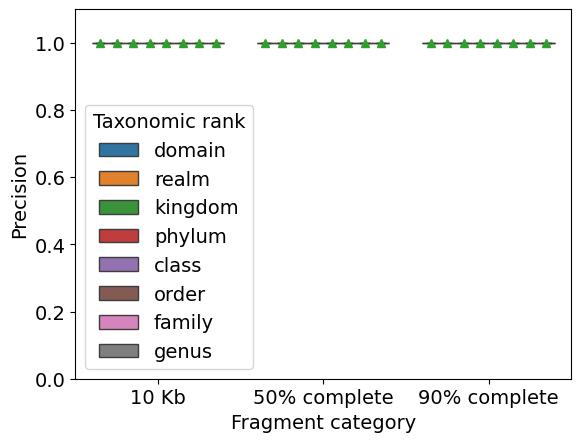

In [25]:
### plot precision at different taxonomic levels and fragment categories
import matplotlib.pyplot as plt
import seaborn as sns

prec_recall_df = pl.DataFrame(tax_analysis_lst)

sns.boxplot(data=prec_recall_df, x='cat', y='precision', hue='Taxonomic rank', showmeans=True)
plt.gca().set_ylim(0, 1.1)
plt.xlabel('Fragment category')
plt.ylabel('Precision')
plt.rcParams.update({'font.size': 14})
plt.show()

# Takeaway: precision is generally high across all taxonomic levels and fragment categories

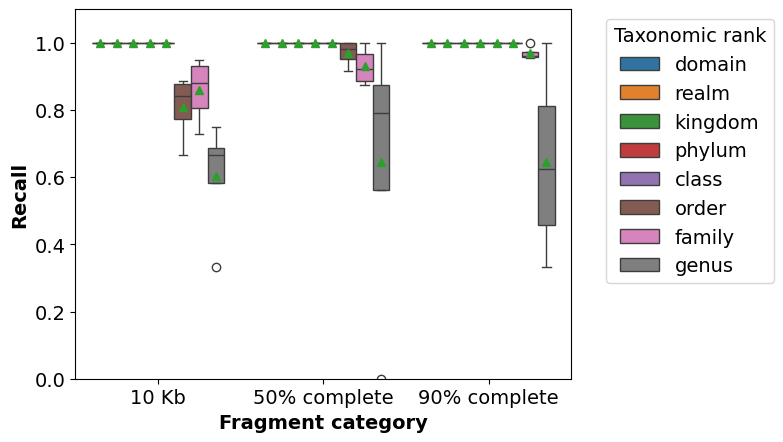

In [29]:
### plot reall at different taxonomic levels and fragment categories
prec_recall_df = pl.DataFrame(tax_analysis_lst)

sns.boxplot(data=prec_recall_df, x='cat', y='recall', hue='Taxonomic rank', showmeans=True)
plt.gca().set_ylim(0, 1.1)
plt.rcParams.update({'font.size': 14})
plt.xlabel('Fragment category', fontdict={'fontweight': 'bold'})
plt.ylabel('Recall', fontdict={'fontweight': 'bold'})
# move legend to outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Taxonomic rank')
plt.show()

# Takeaway: recall decreases with more severe fragmentation, especially at lower taxonomic levels

In [20]:
### Compare recall at family level
(
    prec_recall_df
        .filter(
            (pl.col('Taxonomic rank') == 'family')
        )
        .group_by('cat')
        .agg([pl.col('recall').mean()])
)

cat,recall
str,f64
"""50% complete""",0.929609
"""10 Kb""",0.858475
"""90% complete""",0.96896
